# Session 11 — No Free Lunch & Systematic Algorithm Comparison

This session asks the central question of algorithm selection: *is there a universally best optimisation heuristic?*
The No Free Lunch (NFL) theorem provides the theoretical answer; a structured empirical comparison across three diverse problem types gives the practical one.

**Session map**

| Part | Content |
|------|---------|
| A — NFL theorem | Statement, intuition, empirical demonstration |
| B — Comparison | REL / FEO for FSA, GO, DE across Rastrigin, Knapsack, Feature Selection |
| C — Statistics | Pairwise Wilcoxon tests; when-to-use guide |


In [1]:
import sys
import os
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 120

from objfun_dejong1 import DeJong1
from objfun_rastrigin import Rastrigin
from objfun_knapsack import Knapsack
from objfun_feature_selection import FeatureSelection

from heur_fsa import FastSimulatedAnnealing
from heur_go import GeneticOptimization, RandomCombination
from heur_de import DifferentialEvolution
from heur_aux import CauchyMutation, BitFlipMutation, MirrorCorrection


In [2]:
def run_experiment(algo_factory, n_runs, label=''):
    results = []
    for seed in tqdm(range(n_runs), desc=label, leave=False):
        res = algo_factory(seed).search()
        results.append(res)
    return pd.DataFrame(results)

def rel(df):
    return df['success'].mean()

def mne(df):
    solved = df[df['success']]
    return solved['neval'].mean() if len(solved) > 0 else np.nan

def feo(df, maxeval):
    r = rel(df)
    if r == 0:
        return np.nan
    m = mne(df)
    return m / r if not np.isnan(m) else maxeval / r

def fmt(x):
    # Replace NaN / None with an em-dash for display
    return '—' if (x is None or (isinstance(x, float) and np.isnan(x))) else round(x, 1)

def stats_row(df, maxeval, label):
    r, m, f = rel(df), mne(df), feo(df, maxeval)
    return {'Algorithm': label, 'REL (%)': round(r * 100, 1), 'MNE': fmt(m), 'FEO': fmt(f)}


## Part A — No Free Lunch

### The theorem

Wolpert & Macready (1997) proved that, averaged over **all** possible objective functions, every search algorithm performs identically. In other words:

> **No algorithm can be universally better than any other — specialisation on one problem class always comes at the cost of performance on another.**

Formally, let $P(d_m^y \mid f, m, a)$ be the probability of observing performance trace $d_m^y$ after $m$ evaluations of function $f$ by algorithm $a$. The NFL theorem states:

$$\sum_f P(d_m^y \mid f, m, a_1) = \sum_f P(d_m^y \mid f, m, a_2) \qquad \forall\, a_1,\, a_2$$

The sum runs over **all** possible functions — including adversarial and degenerate ones that never arise in practice. In real engineering we always operate within a restricted problem class, which is precisely why specialised algorithms can win.

### Implication for benchmarking

A single benchmark cannot determine the "best" algorithm. A diverse test suite — spanning problem types, domains, and difficulty levels (dimensions) — is necessary for a fair comparison. The rest of this session builds exactly that.


### Empirical demonstration

We compare **FSA** and **GO** on two problems from the course that sit at opposite ends of the "problem landscape":

| Problem | Domain | Structure |
|---------|--------|-----------|
| De Jong 1, n=5 | Continuous R^n | Smooth, strictly unimodal — one basin, no deception |
| Knapsack, n=50 | Binary {0,1}^n | Combinatorial, constrained — many non-improving neighbours |

If neither algorithm dominates, the winner must flip between these two settings.


In [3]:
# ── NFL demo ──────────────────────────────────────────────────────────────────
N_NFL      = 1000   # runs per algorithm per problem
MAXEVAL_DJ = 500    # De Jong 1 budget
MAXEVAL_KS = 2000   # Knapsack budget

of_dj = DeJong1(n=5, eps=0.01)     # fstar = 0.01
of_ks = Knapsack(n=50, capacity_ratio=0.4, seed=42, penalty=100, target_pct=0.95)

def fsa_dj(seed):
    return FastSimulatedAnnealing(
        of_dj, MAXEVAL_DJ, T0=1, n0=10, alpha=2,
        mutation=CauchyMutation(r=0.1, correction=MirrorCorrection(of_dj)), seed=seed)

def go_dj(seed):
    return GeneticOptimization(
        of_dj, MAXEVAL_DJ, N=10, M=30, Tsel1=0.5, Tsel2=0.5,
        mutation=CauchyMutation(r=0.5, correction=MirrorCorrection(of_dj)),
        crossover=RandomCombination(), seed=seed)

def fsa_ks(seed):
    return FastSimulatedAnnealing(
        of_ks, MAXEVAL_KS, T0=20, n0=200, alpha=2,
        mutation=BitFlipMutation(p=1/50), seed=seed)

def go_ks(seed):
    return GeneticOptimization(
        of_ks, MAXEVAL_KS, N=20, M=60, Tsel1=0.5, Tsel2=0.5,
        mutation=BitFlipMutation(p=1/50), crossover=RandomCombination(), seed=seed)


In [4]:
print('Running NFL demo...')
df_nfl_fsa_dj = run_experiment(fsa_dj, N_NFL, 'FSA / De Jong 1')
df_nfl_go_dj  = run_experiment(go_dj,  N_NFL, 'GO  / De Jong 1')
df_nfl_fsa_ks = run_experiment(fsa_ks, N_NFL, 'FSA / Knapsack')
df_nfl_go_ks  = run_experiment(go_ks,  N_NFL, 'GO  / Knapsack')


Running NFL demo...


FSA / De Jong 1:   0%|          | 0/1000 [00:00<?, ?it/s]

GO  / De Jong 1:   0%|          | 0/1000 [00:00<?, ?it/s]

FSA / Knapsack:   0%|          | 0/1000 [00:00<?, ?it/s]

GO  / Knapsack:   0%|          | 0/1000 [00:00<?, ?it/s]

In [5]:
nfl_rows = []
for label, df_dj, df_ks in [('FSA', df_nfl_fsa_dj, df_nfl_fsa_ks),
                              ('GO',  df_nfl_go_dj,  df_nfl_go_ks)]:
    nfl_rows.append({
        'Algorithm':       label,
        'De Jong 1 — REL': f"{rel(df_dj)*100:.0f}%",
        'De Jong 1 — MNE': fmt(mne(df_dj)),
        'Knapsack  — REL': f"{rel(df_ks)*100:.0f}%",
        'Knapsack  — MNE': fmt(mne(df_ks)),
    })
pd.DataFrame(nfl_rows).set_index('Algorithm')


,De Jong 1 — REL,De Jong 1 — MNE,Knapsack — REL,Knapsack — MNE
Algorithm,,,,
FSA,66%,318.4,46%,1427.3
GO,0%,—,100%,757.2


### Interpretation

The table shows a dramatic winner-flip:

- **De Jong 1** (smooth, unimodal): FSA succeeds 66% of the time (MNE ≈ 318 evaluations). GO achieves 0% REL — not because it cannot find the optimum in principle, but because the population overhead is too expensive for the 500-evaluation budget: initialising 10 individuals consumes the first 10 evals, and each generation burns 30 more, leaving only ~16 generations to converge. On a smooth landscape this overhead is pure waste — the problem does not require population diversity to find the single basin.
- **Knapsack** (combinatorial, constrained): GO dominates at 100% REL (MNE ≈ 757). FSA succeeds only 46% of the time; its single trajectory regularly falls into local optima from which bit-flip mutations offer no improvement.

**The winner is reversed** — exactly as NFL predicts. Neither algorithm is universally better; each is adapted to a different region of the problem space.

*Practical takeaway:* population overhead is a liability when the problem has one basin; it is an asset when the problem is highly rugged or constrained.


## Part B — Systematic Algorithm Comparison

We now run a full comparison across three problem types using all algorithms introduced in the course:

| Problem | Domain | Algorithms | Original session |
|---------|--------|-----------|-----------------|
| Rastrigin n=5 | R^n, multimodal | FSA, GO, DE | 3b / 4b / 7 |
| Knapsack n=50 | {0,1}^n, constrained | FSA, GO | 6b / 10 |
| Feature Selection (Wine) | {0,1}^n, binary | FSA, GO | 6a |

**Note:** DE could technically work, but is omitted from the two binary problems.

**Parameter consistency:** All parameters match the original session that studied each problem most thoroughly. For Rastrigin, this means using **Session 9 parameters**: eps=5.0 (fstar=5.0), N=10, M=20, maxeval=5000. Session 4b used different parameters (eps=0.5, N=50, maxeval=10,000) and is therefore not directly comparable — both sessions test Rastrigin n=5, but at different difficulty levels and with different algorithm configurations.

Each cell runs 1 000 independent experiments.


In [6]:
# ── Problem instances ──────────────────────────────────────────────────────────
N_COMP = 1000

of_rastrigin = Rastrigin(n=5, eps=5.0)      # fstar = 5.0  (Session 9)
MAXEVAL_RAS  = 5000

of_knapsack  = Knapsack(n=50, capacity_ratio=0.4, seed=42, penalty=100, target_pct=0.95)
MAXEVAL_KSP  = 2000

of_featsel   = FeatureSelection(dataset='wine', k=3, cv=5, target_accuracy=0.95)
MAXEVAL_FS   = 500


In [7]:
# ── Rastrigin — parameters from Session 9 ─────────────────────────────────────
def ras_fsa(seed):
    return FastSimulatedAnnealing(
        of_rastrigin, MAXEVAL_RAS, T0=1, n0=1000, alpha=2,
        mutation=CauchyMutation(r=0.1, correction=MirrorCorrection(of_rastrigin)), seed=seed)

def ras_go(seed):
    return GeneticOptimization(
        of_rastrigin, MAXEVAL_RAS, N=10, M=20, Tsel1=0.5, Tsel2=0.5,
        mutation=CauchyMutation(r=0.5, correction=MirrorCorrection(of_rastrigin)),
        crossover=RandomCombination(), seed=seed)

def ras_de(seed):
    return DifferentialEvolution(
        of_rastrigin, MAXEVAL_RAS, N=10, CR=0.9, F=0.8, mutation='rand/1', seed=seed)

# ── Knapsack — parameters from Sessions 6b / 10 ───────────────────────────────
def ks_fsa(seed):
    return FastSimulatedAnnealing(
        of_knapsack, MAXEVAL_KSP, T0=20, n0=200, alpha=2,
        mutation=BitFlipMutation(p=1/50), seed=seed)

def ks_go(seed):
    return GeneticOptimization(
        of_knapsack, MAXEVAL_KSP, N=20, M=60, Tsel1=0.5, Tsel2=0.5,
        mutation=BitFlipMutation(p=1/50), crossover=RandomCombination(), seed=seed)

# ── Feature Selection — parameters from Session 6a ────────────────────────────
def fs_fsa(seed):
    return FastSimulatedAnnealing(
        of_featsel, MAXEVAL_FS, T0=0.3, n0=50, alpha=2,
        mutation=BitFlipMutation(p=1/13), seed=seed)

def fs_go(seed):
    return GeneticOptimization(
        of_featsel, MAXEVAL_FS, N=10, M=30, Tsel1=0.3, Tsel2=0.3,
        mutation=BitFlipMutation(p=1/13), crossover=RandomCombination(), seed=seed)


In [8]:
print('Running systematic comparison (this may take a few minutes)...')

df_ras_fsa = run_experiment(ras_fsa, N_COMP, 'Rastrigin / FSA')
df_ras_go  = run_experiment(ras_go,  N_COMP, 'Rastrigin / GO')
df_ras_de  = run_experiment(ras_de,  N_COMP, 'Rastrigin / DE')

df_ks_fsa  = run_experiment(ks_fsa,  N_COMP, 'Knapsack  / FSA')
df_ks_go   = run_experiment(ks_go,   N_COMP, 'Knapsack  / GO')

df_fs_fsa  = run_experiment(fs_fsa,  N_COMP, 'FeatSel   / FSA')
df_fs_go   = run_experiment(fs_go,   N_COMP, 'FeatSel   / GO')


Running systematic comparison (this may take a few minutes)...


Rastrigin / FSA:   0%|          | 0/1000 [00:00<?, ?it/s]

Rastrigin / GO:   0%|          | 0/1000 [00:00<?, ?it/s]

Rastrigin / DE:   0%|          | 0/1000 [00:00<?, ?it/s]

Knapsack  / FSA:   0%|          | 0/1000 [00:00<?, ?it/s]

Knapsack  / GO:   0%|          | 0/1000 [00:00<?, ?it/s]

FeatSel   / FSA:   0%|          | 0/1000 [00:00<?, ?it/s]

FeatSel   / GO:   0%|          | 0/1000 [00:00<?, ?it/s]

In [9]:
rows = [
    {**stats_row(df_ras_fsa, MAXEVAL_RAS, 'FSA'), 'Problem': 'Rastrigin n=5'},
    {**stats_row(df_ras_go,  MAXEVAL_RAS, 'GO'),  'Problem': 'Rastrigin n=5'},
    {**stats_row(df_ras_de,  MAXEVAL_RAS, 'DE'),  'Problem': 'Rastrigin n=5'},
    {**stats_row(df_ks_fsa,  MAXEVAL_KSP, 'FSA'), 'Problem': 'Knapsack n=50'},
    {**stats_row(df_ks_go,   MAXEVAL_KSP, 'GO'),  'Problem': 'Knapsack n=50'},
    {**stats_row(df_fs_fsa,  MAXEVAL_FS,  'FSA'), 'Problem': 'Feature Sel.'},
    {**stats_row(df_fs_go,   MAXEVAL_FS,  'GO'),  'Problem': 'Feature Sel.'},
]
df_comp = pd.DataFrame(rows).set_index(['Problem', 'Algorithm'])
df_comp


REL (%)     MNE      FEO
Problem       Algorithm                          
Rastrigin n=5 FSA           94.0  1894.4   2015.4
              GO             4.9  2841.8  57996.3
              DE            70.1  1385.7   1976.7
Knapsack n=50 FSA           45.5  1427.3   3136.9
              GO           100.0   757.2    757.2
Feature Sel.  FSA          100.0    17.2     17.2
              GO           100.0     7.6      7.6

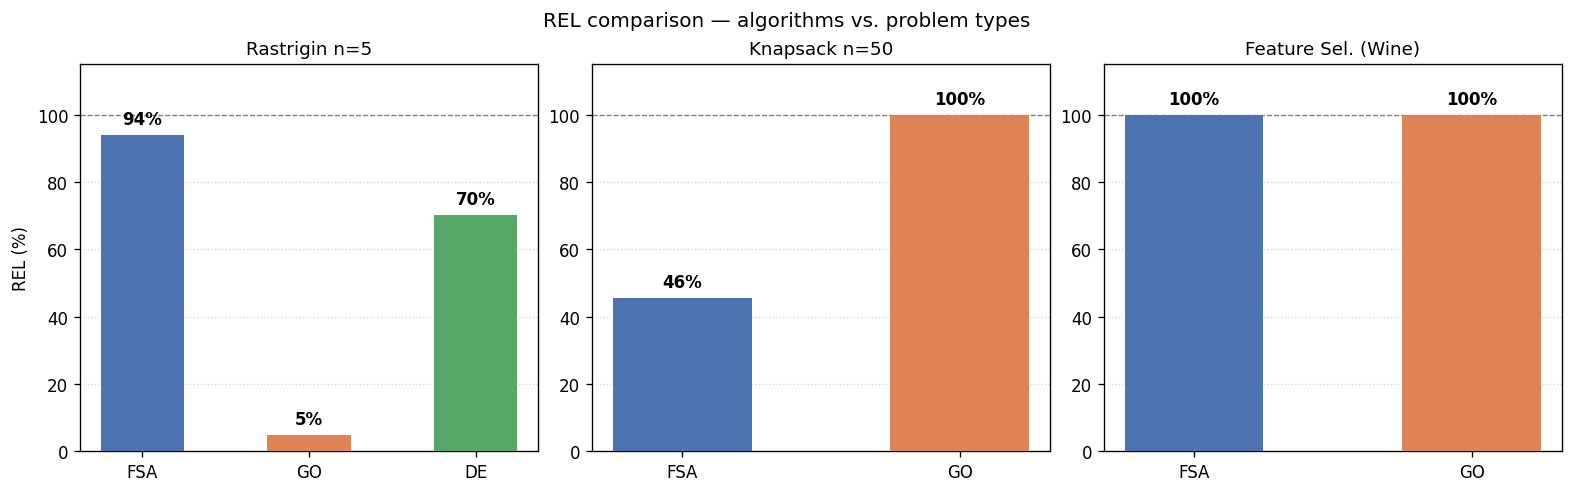

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False, constrained_layout=True)

problems = [
    ('Rastrigin n=5',      [df_ras_fsa, df_ras_go, df_ras_de], ['FSA', 'GO', 'DE']),
    ('Knapsack n=50',      [df_ks_fsa,  df_ks_go],             ['FSA', 'GO']),
    ('Feature Sel. (Wine)',[df_fs_fsa,  df_fs_go],             ['FSA', 'GO']),
]
palette = {'FSA': '#4C72B0', 'GO': '#DD8452', 'DE': '#55A868'}

for ax, (title, dfs, labels) in zip(axes, problems):
    rels = [rel(df) * 100 for df in dfs]
    bars = ax.bar(labels, rels, color=[palette[l] for l in labels], width=0.5, zorder=3)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('REL (%)' if ax is axes[0] else '')
    ax.set_ylim(0, 115)
    ax.axhline(100, color='gray', linestyle='--', linewidth=0.8, zorder=2)
    ax.grid(axis='y', linestyle=':', alpha=0.5, zorder=1)
    for bar, r in zip(bars, rels):
        ax.text(bar.get_x() + bar.get_width() / 2, r + 2, f'{r:.0f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

fig.suptitle('REL comparison — algorithms vs. problem types', fontsize=12)
plt.show()


### Interpretation

Reading across the columns reveals the key pattern:

- **Rastrigin (multimodal continuous):** FSA leads at 94.0% REL — fine-grained Cauchy steps (r=0.1) plus Metropolis acceptance converge reliably within individual basins given the Session 9 criterion (eps=5.0, i.e. reach the global basin region). DE reaches 70%: vector arithmetic provides directed exploration but with N=10 the population loses diversity quickly. GO nearly fails (4.9%) with these parameters (N=10, M=20): its broad Cauchy mutation (r=0.5) prevents convergence within any single basin, consistent with Session 9's finding.

  *Context from Session 4b:* with a stricter criterion (eps=0.5) and a larger well-tuned population (N=50), GO achieved 74.2% REL on the same problem — showing that GO *can* work on continuous multimodal landscapes, but only with careful population-size tuning. The Session 9 parameters (small N, designed to motivate memetic extensions) put GO at a disadvantage here.

- **Knapsack (combinatorial, constrained):** GO dominates at 100% REL — population diversity navigates the constrained binary space. FSA's single trajectory (45.5%) falls into local-optima traps that individual bit-flips cannot escape. Results are consistent with Sessions 6b and 10.

- **Feature Selection (binary, small space):** both algorithms achieve 100% REL and are statistically indistinguishable (Wilcoxon p=1.0). The 2¹³ = 8 192-point search space is permissive enough that both approaches succeed within 500 evaluations. Results are consistent with Session 6a.

**No single algorithm wins across all three columns.** FSA excels on the continuous multimodal problem (with fine-grained mutation) but fails on the combinatorial one; GO dominates the combinatorial problem but requires larger populations to be competitive on continuous ones; DE occupies a middle ground on continuous problems only. This is the empirical manifestation of the NFL theorem.


## Part C — Statistical Significance

Visual differences in REL can be sampling artefacts, especially when gaps are small. We use pairwise **Wilcoxon rank-sum tests** (Mann–Whitney U) on the binary success vectors (0 or 1 per run) to determine whether observed differences are statistically meaningful.

**Null hypothesis H₀:** the two algorithms have the same probability of success on a given problem.
**Rejection threshold:** α = 0.05.

With n = 1 000 runs the test has roughly 80% power to detect a true REL difference of ≈ 4–5 percentage points.


In [11]:
def wilcoxon_p(df_a, df_b):
    a = df_a['success'].astype(int).values
    b = df_b['success'].astype(int).values
    if a.sum() == b.sum():
        return 1.0   # identical outcome counts — no evidence of difference
    _, p = mannwhitneyu(a, b, alternative='two-sided')
    return p

tests = [
    ('Rastrigin n=5',      'FSA vs GO',  wilcoxon_p(df_ras_fsa, df_ras_go)),
    ('Rastrigin n=5',      'FSA vs DE',  wilcoxon_p(df_ras_fsa, df_ras_de)),
    ('Rastrigin n=5',      'GO  vs DE',  wilcoxon_p(df_ras_go,  df_ras_de)),
    ('Knapsack n=50',      'FSA vs GO',  wilcoxon_p(df_ks_fsa,  df_ks_go)),
    ('Feature Sel. (Wine)','FSA vs GO',  wilcoxon_p(df_fs_fsa,  df_fs_go)),
]
df_tests = pd.DataFrame(tests, columns=['Problem', 'Comparison', 'p-value'])
df_tests['Significant'] = df_tests['p-value'].apply(lambda p: 'yes  (p < 0.05)' if p < 0.05 else 'no')
df_tests['p-value'] = df_tests['p-value'].map(lambda p: f'{p:.4f}')
df_tests.set_index(['Problem', 'Comparison'])


p-value      Significant
Problem             Comparison                         
Rastrigin n=5       FSA vs GO   0.0000  yes  (p < 0.05)
                    FSA vs DE   0.0000  yes  (p < 0.05)
                    GO  vs DE   0.0000  yes  (p < 0.05)
Knapsack n=50       FSA vs GO   0.0000  yes  (p < 0.05)
Feature Sel. (Wine) FSA vs GO   1.0000               no

### Interpretation

- Rows marked **yes** confirm the visual REL differences in the bar chart are not sampling noise — the algorithms genuinely differ on that problem.
- Rows marked **no** warn us not to over-interpret small gaps: the data are consistent with the two algorithms performing identically.
- On Feature Selection, where both algorithms achieve high REL, the difference is small and may not reach significance — reflecting that the problem is permissive enough for either approach.

**Important caveat:** a significant Wilcoxon result tells us the success *rates* differ; it says nothing about the magnitude of the difference. An algorithm with 95% REL vs. 90% REL may be statistically significant with large enough n, but practically interchangeable. Always consider both p-value *and* effect size.


## Summary — When to use which algorithm?

| Algorithm | Strengths | Weaknesses | Best fit |
|-----------|-----------|-----------|----------|
| **FSA** | Low overhead; Metropolis acceptance escapes shallow local optima; strong on continuous problems with fine-grained mutation | Single trajectory; no population diversity; struggles with combinatorial explosions | Smooth and multimodal R^n (well-tuned temperature + small step size); moderate dimensionality |
| **GO** | Population diversity; crossover generates novel candidates; robust on combinatorial problems; can work on continuous multimodal with large N | Population overhead wastes tight budgets; underperforms with small N on continuous problems; sensitive to Tsel tuning | Binary {0,1}^n; discrete combinatorial; heavily constrained; continuous only with N ≥ 50 and ample budget |
| **DE** | Exploits vector geometry; self-adaptive effective step size; robust to population-size tuning | Requires real-valued domain; no natural extension to binary | Continuous R^n with multiple local optima, especially when FSA step-size tuning is difficult |
| **Memetic** | Combines global diversity with local refinement; strong where local search is meaningful | Computational overhead per offspring | TSP (2-opt), Knapsack (repair); budget ≥ 5–10× pure GO |

**Rule of thumb:** start with FSA — cheap and often sufficient. If REL stagnates below ~60% after parameter tuning:
- For **continuous** problems → try DE (robust to population-size choice, whereas GO needs N ≥ 50 to compete)
- For **binary/combinatorial** problems → switch to GO

The budget matters: GO's population overhead is a liability on tight-budget continuous problems, but its crossover-driven diversity is essential for combinatorial ones.


## Assignments

1. **Extend to h-means** (Session 5a, R^n real application): run FSA, GO, and DE on h-means clustering. Do the rankings match those on Rastrigin? Why or why not?

2. **Add MemeticGO**: copy the `MemeticGO` implementation from Session 9 and include it in the Rastrigin comparison. Does it outperform DE here, or does the advantage only appear on discrete problems?

3. **Statistical power**: increase `N_COMP` to 500 for any comparison whose Wilcoxon p-value lies between 0.01 and 0.10. Does the significance verdict change?

4. **Effect size**: compute Cohen's h (the effect size for difference in proportions) for each pairwise comparison. Which differences are large in practice, and which are merely statistically significant?

5. **Construct an adversarial problem**: design a synthetic objective function on {0,1}^10 where FSA and GO achieve similar REL (within 5 pp) but opposite MNE — one finds solutions much faster than the other. What does this reveal about the limitations of using REL as the sole comparison criterion?
